In [1]:
import torch

# define nn
import torch.nn as nn

# generate nn data
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [2]:
# generate some random data with surfaces in 3 dimensions.
torch.manual_seed(0)
n = 1000000
x = torch.randn(n, 3)
y = x[:, 0] ** 2 + x[:, 1] ** 2 + x[:, 2] ** 2 + torch.randn(n) * 0.1

# split the data into train and test sets
train_size = int(0.8 * n)
test_size = n - train_size
train_x, test_x = torch.split(x, [train_size, test_size])
train_y, test_y = torch.split(y, [train_size, test_size])

# move data to device
train_x, test_x = train_x.to(device), test_x.to(device)
train_y, test_y = train_y.to(device), test_y.to(device)

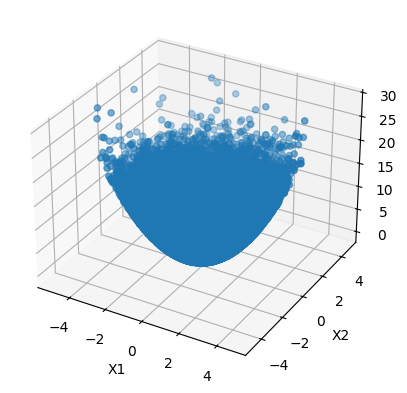

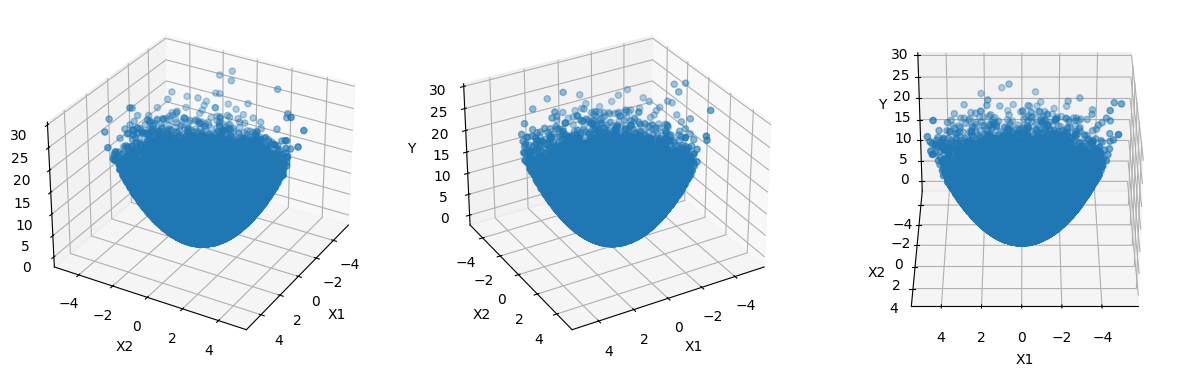

In [3]:
# plot surfaces (move to cpu for matplotlib)
import matplotlib.pyplot as plt

_tx = train_x.cpu()
_ty = train_y.cpu()

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(_tx[:, 0], _tx[:, 1], _ty)
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("Y")
plt.show()
# show 3 different views of the same surface
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131, projection="3d")
ax1.scatter(_tx[:, 0], _tx[:, 1], _ty)
ax1.set_xlabel("X1")
ax1.set_ylabel("X2")
ax1.set_zlabel("Y")
ax1.view_init(30, 30)
ax2 = fig.add_subplot(132, projection="3d")
ax2.scatter(_tx[:, 0], _tx[:, 1], _ty)
ax2.set_xlabel("X1")
ax2.set_ylabel("X2")
ax2.set_zlabel("Y")
ax2.view_init(30, 60)
ax3 = fig.add_subplot(133, projection="3d")
ax3.scatter(_tx[:, 0], _tx[:, 1], _ty)
ax3.set_xlabel("X1")
ax3.set_ylabel("X2")
ax3.set_zlabel("Y")
ax3.view_init(30, 90)
plt.show()

In [4]:
dataset = TensorDataset(train_x, train_y)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)


# the input dimension is 3 because we have 3 features (x1, x2, x3)
# and the output dimension is 1 because we want to predict a
# single value (y) from the input (x1, x2, x3)
input_dimension = 3
# the batch size is the number of neurons in the hidden layer,
# which is a common choice for small datasets. For larger datasets,
# you can increase the batch size to speed up training, but it may require more memory.
batch_size = 64
# the output dimension is 1 because we want to predict a single value (y) from the input (x1, x2, x3)
output_dimension = 1


# define the neural network architecture by creating a class that inherits from nn.Module
class Net(nn.Module):
    # the __init__ method defines the layers of the network
    def __init__(self):
        # call the __init__ method of the parent class (nn.Module) to initialize the network
        super(Net, self).__init__()
        # the input dimension is 3 (x1, x2, x3) and the output dimension is 1 (y)
        self.fc1 = nn.Linear(input_dimension, batch_size)
        # the hidden layer has batch_size neurons and the output layer has 1 neuron
        self.fc2 = nn.Linear(batch_size, batch_size)
        # the output layer has 1 neuron
        self.fc3 = nn.Linear(batch_size, output_dimension)

    # the forward method defines how the input data flows through the network
    def forward(self, x):
        # apply ReLU activation function to the output of the first hidden layer
        x = torch.relu(self.fc1(x))
        # apply ReLU activation function to the output of the second hidden layer
        x = torch.relu(self.fc2(x))
        # the output layer does not have an activation function because we are doing regression
        x = self.fc3(x)
        return x


# create an instance of the Net class and move it to device
net = Net().to(device)
# define the loss function (mean squared error) and the optimizer (Adam)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)
# train the network for a certain number of epochs
num_epochs = 10
for epoch in range(num_epochs):
    for i, (inputs, targets) in enumerate(dataloader):
        # zero the parameter gradients
        optimizer.zero_grad()
        # forward pass: compute the output of the network
        outputs = net(inputs)
        # compute the loss between the predicted output and the true target
        loss = criterion(outputs.squeeze(), targets)
        # backward pass: compute the gradients of the loss with respect to the parameters
        loss.backward()
        # update the parameters using the optimizer
        optimizer.step()
    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}")

# evaluate the trained model on the training data
net.eval()  # set the model to evaluation mode
with torch.no_grad():  # disable gradient computation for evaluation
    predictions = net(
        train_x
    ).squeeze()  # get the predictions from the model and remove extra dimensions
    mse = criterion(
        predictions, train_y
    )  # compute the mean squared error between predictions and true values
    print(f"Mean Squared Error on training data: {mse.item():.4f}")

Epoch [1/10], Loss: 0.0163
Epoch [2/10], Loss: 0.0124
Epoch [3/10], Loss: 0.0116
Epoch [4/10], Loss: 0.0120
Epoch [5/10], Loss: 0.0105
Epoch [6/10], Loss: 0.0099
Epoch [7/10], Loss: 0.0125
Epoch [8/10], Loss: 0.0101
Epoch [9/10], Loss: 0.0098
Epoch [10/10], Loss: 0.0150
Mean Squared Error on training data: 0.0114


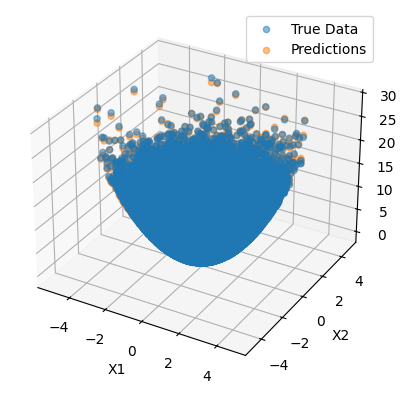

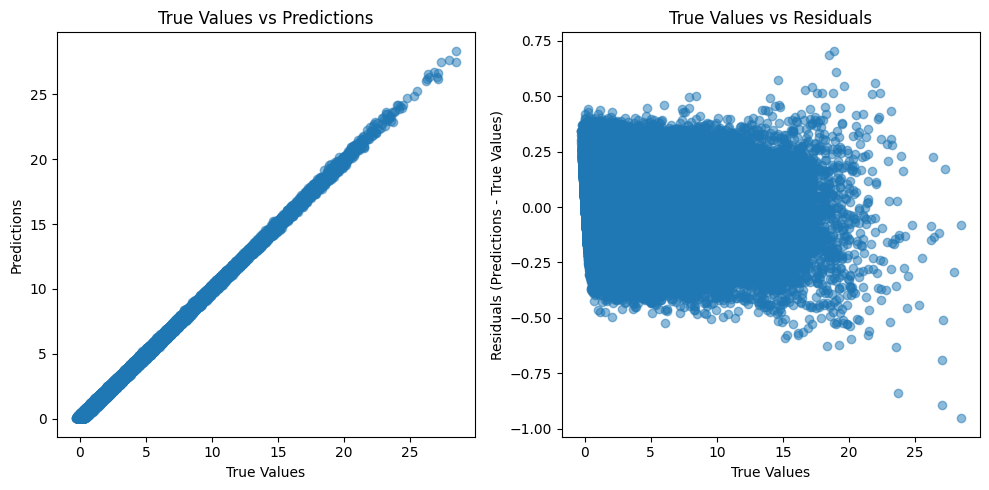

In [5]:
# plot the data and the predictions (move to cpu for matplotlib)
_tx = train_x.cpu()
_ty = train_y.cpu()
_pred = predictions.cpu()

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(_tx[:, 0], _tx[:, 1], _ty, label="True Data", alpha=0.5)
ax.scatter(_tx[:, 0], _tx[:, 1], _pred, label="Predictions", alpha=0.5)
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("Y")
ax.legend()
plt.show()

# plot the true values and the predictions in a 2D scatter plot
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(_ty, _pred, alpha=0.5)
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title("True Values vs Predictions")
plt.subplot(1, 2, 2)
plt.scatter(_ty, _pred - _ty, alpha=0.5)
plt.xlabel("True Values")
plt.ylabel("Residuals (Predictions - True Values)")
plt.title("True Values vs Residuals")
plt.tight_layout()
plt.show()

In [6]:
# get mse on test data
with torch.no_grad():
    test_predictions = net(test_x).squeeze()
    test_mse = criterion(test_predictions, test_y)
    print(f"Mean Squared Error on test data: {test_mse.item():.4f}")

Mean Squared Error on test data: 0.0115
